# RAG Bench — 72-Combo Benchmark on Google Colab

한국어 RAG 파이프라인 72개 조합을 Google Colab T4 GPU에서 벤치마크합니다.

## 3-Layer Architecture
```
Layer 1: Dense Model ─── kosimcse | e5 | bge-m3 | minilm       (4종)
Layer 2: Sparse Model ── korean_bm25 | splade | fastembed_bm25 (3종)
Layer 3: Retrieval Mode ─ hybrid × reranker × llm_support      (6종)
                          ├── hybrid (기본)
                          ├── hybrid + contextual
                          ├── hybrid + colbert_rerank
                          ├── hybrid + colbert_rerank + contextual
                          ├── hybrid + flashrank_rerank
                          └── hybrid + flashrank_rerank + contextual

총 조합: 4 × 3 × 6 = 72개
```

## 2-Pass Execution
- **Pass 1**: 전체 조합 레이턴시 측정 (API 비용 $0)
- **Pass 2**: 상위 N개만 RAGAS 평가 (API 비용 절감)
  - **메트릭 프리셋**: `core_only` (4) | `comprehensive` (7) | `full` (11+) | `reference_free`
  - **스코어링 프로파일**: `balanced` | `precision_critical` | `speed_critical` | `comprehensive`

## 예상 실행시간 (T4 GPU)
| 프리셋 | 조합 수 | Pass 1 | Pass 2 | 총 예상 |
|--------|---------|--------|--------|--------|
| quick | 4 | ~3분 | ~10분 | ~15분 |
| standard | 24 | ~20분 | ~30분 | ~50분 |
| full | 72 | ~1시간 | ~2시간 | ~3시간 |

---
## Section 1: 환경 설정

In [22]:
# Cell 1.1: Repo clone + sys.path 설정
import os
import sys

REPO_URL = "https://github.com/SukbeomH/RAG-Bench.git"  # <- 본인 repo URL로 변경
REPO_DIR = "/content/RAG-Bench"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repo already cloned: {REPO_DIR}")
    !git -C {REPO_DIR} pull

# sys.path에 추가 (패키지 import용)
for p in [REPO_DIR, os.path.join(REPO_DIR, "rag_bench_colab")]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"sys.path 설정 완료")
print(f"Python: {sys.version}")

Repo already cloned: /content/RAG-Bench
Already up to date.
sys.path 설정 완료
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [23]:
# Cell 1.2: 시스템 의존성 + 패키지 설치
import os
import subprocess

!apt-get install -y default-jdk -qq

# Colab 사전 설치 torch 버전 보존 (CUDA 호환성)
# sentence-transformers, pylate 등이 PyPI의 torch를 끌어오는 것을 방지
_torch_ver = subprocess.check_output(
    ['python', '-c', 'import torch; print(torch.__version__)']
).decode().strip()
print(f"[torch] Colab 사전 설치 버전: {_torch_ver} (보존)")

os.system(
    f'pip install -q '
    f'-r /content/RAG-Bench/rag_bench_colab/requirements_colab.txt '
    f'"torch=={_torch_ver}"'
)
print("[완료] 패키지 설치 완료")

[torch] Colab 사전 설치 버전: 2.9.0+cu128 (보존)
[완료] 패키지 설치 완료


In [24]:
# Cell 1.3: Colab 환경 초기화 + rag_bench 패치 + smoke test
from colab_config import init_colab

env_info = init_colab(
    qdrant_mode="ephemeral",  # 'ephemeral' | 'drive' | 'memory'
    device=None,               # None = 자동 감지 (T4 → 'cuda')
    mount_drive=True,
)

# Smoke test: 핵심 모듈 import
from rag_bench.config import BENCH_DATA_DIR, BENCH_DOCS_DIR
from rag_bench.scripts.run_all_combos import PRESETS, generate_valid_combinations, ComboSpec
from rag_bench.runner import BenchmarkRunner
print("\n[Smoke Test] 모든 import 성공!")
print(f"  BENCH_DATA_DIR: {BENCH_DATA_DIR}")
print(f"  BENCH_DOCS_DIR: {BENCH_DOCS_DIR}")

[Device] CUDA: NVIDIA A100-SXM4-40GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[API Key] Colab Secrets 접근 실패. .env 파일로 폴백합니다.

[Setup] 환경 설정 완료:
  is_colab: True
  device: cuda
  drive_mounted: True
  api_key_loaded: True
  hf_home: /content/drive/MyDrive/rag_bench_colab/models
[Patch] rag_bench.config 패치 완료:
  BENCH_DOCS_DIR → /content/RAG-Bench/rag_bench_colab/data/docs
  BENCH_DATA_DIR → /content/drive/MyDrive/rag_bench_colab/_benchdata
  MODELS_DIR     → /content/drive/MyDrive/rag_bench_colab/models
  Qdrant mode    → ephemeral
[Patch] huggingface_hub.list_repo_tree → additional_chat_templates 404 억제
[Patch] DenseSparseStrategy._init_dense → device='cuda', trust_remote_code=True

 Colab 환경 초기화 완료

[Smoke Test] 모든 import 성공!
  BENCH_DATA_DIR: /content/drive/MyDrive/rag_bench_colab/_benchdata
  BENCH_DOCS_DIR: /content/RAG-Bench/rag_bench_colab/data/docs


In [25]:
# Cell 1.4: API Key 설정 (자동 로드 실패 시 수동 입력)
import os

if not env_info.get("api_key_loaded", False):
    import getpass
    _key = getpass.getpass("OPENAI_API_KEY 입력 (Enter로 건너뜀): ")
    if _key.strip():
        os.environ["OPENAI_API_KEY"] = _key.strip()
        print("[API Key] 수동 입력 완료")
    else:
        print("[Warning] OPENAI_API_KEY 미설정 — Pass 2 RAGAS 평가가 실패할 수 있습니다.")
else:
    print("[API Key] 이미 로드됨")

[API Key] 이미 로드됨


In [ ]:
# Cell 1.5: Upstage API Key 설정
import os

try:
    from google.colab import userdata
    _upstage_key = userdata.get('UPSTAGE_API_KEY', '')
except Exception:
    _upstage_key = ''

if _upstage_key:
    os.environ['UPSTAGE_API_KEY'] = _upstage_key
    print('[Upstage API Key] Colab Secrets에서 로드됨')
else:
    # .env 파일에서 로드 시도
    _env_key = os.environ.get('UPSTAGE_API_KEY', '')
    if _env_key:
        print('[Upstage API Key] 환경변수에서 로드됨')
    else:
        print('[Upstage API Key] 미설정 — UpstageEmbedStrategy 사용 시 필요합니다.')

---
## Section 2: 설정

### QDRANT_MODE 선택 가이드

| 모드 | 저장 위치 | 세션 종료 후 | 추천 상황 |
|------|-----------|-------------|-----------|
| `ephemeral` | `/content/qdrant_workspace` (로컬) | **삭제됨** | 빠른 테스트, 재현 불필요 |
| `drive` | `Google Drive/MyDrive/rag_bench_colab/` | **유지됨** | 장시간 실험, 결과 보존 필요 |
| `memory` | 메모리 (RAM) | **삭제됨** | 가장 빠름, 소규모 실험 |

> **권장**: 처음 실행은 `ephemeral`, 결과를 보존하려면 `drive`
>
> `drive` 모드는 Cell 1.3의 `mount_drive=True` 필요 (Google Drive 마운트)

### 기타 파라미터

| 파라미터 | 설명 |
|----------|------|
| `PRESET` | 벤치마크 조합 수 — `quick` (4) / `standard` (24) / `full` (72) |
| `K` | 검색 시 반환할 문서 수 |
| `TOP_N` | Pass 1 완료 후 RAGAS 평가할 상위 전략 수 |
| `METRIC_PRESET` | 평가 메트릭 세트 — `core_only` / `comprehensive` / `full` / `reference_free` |
| `SCORING_PROFILE` | 가중 점수 프로파일 — `balanced` / `precision_critical` / `speed_critical` / `comprehensive` |

In [ ]:
# ===== 사용자 설정 =====
PRESET = "full"     # 'quick' (4조합) | 'standard' (24) | 'full' (72)
K = 3                # 검색 결과 수
TOP_N = 6            # Pass 2 RAGAS 평가 대상 (상위 N)

# QDRANT_MODE:
#   'ephemeral' → /content/qdrant_workspace  (세션 종료 시 삭제, 기본값)
#   'drive'     → Google Drive/rag_bench_colab/ (영구 보존, mount_drive=True 필요)
#   'memory'    → RAM 전용 (가장 빠름, 세션 종료 시 삭제)
QDRANT_MODE = "drive"

# 평가 설정 (rag_bench evaluation 최신화 반영)
METRIC_PRESET = "full"    # 'core_only' (4) | 'comprehensive' (7) | 'full' (11+) | 'reference_free'
SCORING_PROFILE = "balanced"   # 'balanced' | 'precision_critical' | 'speed_critical' | 'comprehensive'
# ======================

print(f"Preset: {PRESET}")
print(f"K: {K}, Top-N: {TOP_N}")
print(f"Qdrant Mode: {QDRANT_MODE}")
print(f"Metric Preset: {METRIC_PRESET}")
print(f"Scoring Profile: {SCORING_PROFILE}")

---
## Section 3: 데이터 로딩

In [ ]:
# Cell 3.1: 러너 생성 + 데이터 로드
from colab_runner import ColabBenchmarkRunner

runner = ColabBenchmarkRunner(
    preset=PRESET,
    k=K,
    top_n=TOP_N,
    qdrant_mode=QDRANT_MODE,
    metric_preset=METRIC_PRESET,
    scoring_profile=SCORING_PROFILE,
)

child_chunks, parent_pairs, queries, ground_truths = runner.prepare_data()

print(f"\nQA 샘플:")
for i, q in enumerate(queries[:3]):
    print(f"  Q{i+1}: {q[:80]}...")
    print(f"  A{i+1}: {ground_truths[i][:80]}...")

In [28]:
# Cell 3.2: Parent-Child 청킹 통계
print(f"Parent 청크: {len(parent_pairs)}개")
print(f"Child 청크: {len(child_chunks)}개")
print(f"\n샘플 Child 청크 (첫 번째):")
print(child_chunks[0].page_content[:300])

Parent 청크: 33개
Child 청크: 763개

샘플 Child 청크 (첫 번째):
**Knowledge Cutoff |** 2025. 9. 10


---
## Section 4: 조합 생성

In [29]:
# 프리셋 기반 ComboSpec 생성
combos = runner.generate_combos()

import pandas as pd
combo_table = pd.DataFrame([
    {
        "#": i+1,
        "Label": spec.label,
        "Dense": spec.dense,
        "Sparse": spec.sparse,
        "Reranker": spec.reranker or "-",
        "LLM Support": spec.llm_support or "-",
    }
    for i, spec in enumerate(combos)
])
display(combo_table)

[Combos] 프리셋 'full': 72개 조합 + GraphRAG 1개 = 총 73개


,#,Label,Dense,Sparse,Reranker,LLM Support
0,1,kosimcse+korean_bm25,kosimcse,korean_bm25,-,-
1,2,kosimcse+korean_bm25+contextual,kosimcse,korean_bm25,-,contextual
2,3,kosimcse+korean_bm25+colbert,kosimcse,korean_bm25,colbert,-
3,4,kosimcse+korean_bm25+colbert+contextual,kosimcse,korean_bm25,colbert,contextual
4,5,kosimcse+korean_bm25+flashrank,kosimcse,korean_bm25,flashrank,-
...,...,...,...,...,...,...
68,69,minilm+fastembed_bm25+colbert,minilm,fastembed_bm25,colbert,-
69,70,minilm+fastembed_bm25+colbert+contextual,minilm,fastembed_bm25,colbert,contextual
70,71,minilm+fastembed_bm25+flashrank,minilm,fastembed_bm25,flashrank,-
71,72,minilm+fastembed_bm25+flashrank+contextual,minilm,fastembed_bm25,flashrank,contextual


---
## Section 5: Pass 1 — 레이턴시 벤치마크

In [ ]:
# Pass 1: 전체 조합 레이턴시 측정
latency_df = runner.run_pass1(combos, queries, child_chunks, parent_pairs)
display(latency_df)


[Pass 1] 레이턴시 벤치마크 시작
  조합: 73개, 쿼리: 20개
  이미 완료: 0개


Pass 1: 전략 빌드 & 검색:   0%|          | 0/73 [00:00<?, ?it/s]


[DS(KoSimCSE-roberta-multitask+korean_bm25)] 초기화 중...


config.json:   0%|          | 0.00/764 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

  Dense: BM-K/KoSimCSE-roberta-multitask (768d, device=cuda)
KoreanBM25Encoder initialized (OKt, k1=1.5, b=0.75)
  Sparse: korean_bm25
  Created collection: document_child_chunks (dim=768)
  Created collection: document_child_chunks (dim=768)
BM25 fit complete: 763 docs, 8317 tokens
  Indexing 763 documents...
  Indexing complete.

전략: DS(KoSimCSE-roberta-multitask+korean_bm25)
설명: Hybrid: KoSimCSE-roberta-multitask (dense) + korean_bm25 (sparse)
  [   40.4ms] 주어진 데이터에서 가장 큰 숫자는 무엇인가요?... → 3 results
  [   51.0ms] 엔비디아의 NVLink Fusion 전략은 무엇을 목표로 하고 있나요?... → 3 results
  [   51.1ms] AI DC가 전력망에 대한 의존도를 낮추기 위해 지향하는 방식은 무엇인가요?... → 3 results
  [   47.4ms] OpenAI의 GPT-6가 목표로 하는 세 가지 핵심 축은 무엇인가요?... → 3 results
  [   46.1ms] IgniteTech의 CEO 에릭 보건은 기존 인력을 어떻게 변화시키기로 결정했나요?... → 3 results
  [   47.6ms] 메타가 AI 엔지니어를 영입하기 위해 어떤 방식으로 접근했는가?... → 3 results
  [   45.9ms] 중국 AI 시장에서 DeepSeek의 주요 성과는 무엇인가요?... → 3 results
  [   47.6ms] 일론 머스크가 작성한 X 게시물의 주요 테마는 무엇인가요?... → 3 results
  [   43.4ms] 팔란

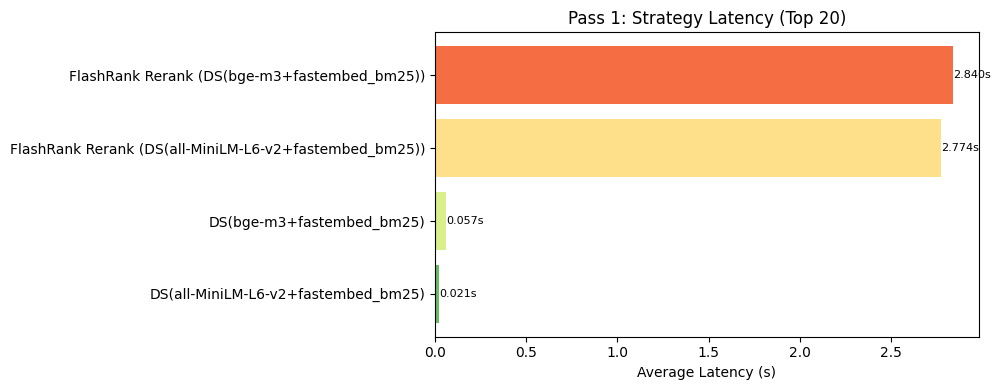

In [ ]:
# Pass 1 시각화
from colab_visualizer import plot_latency_comparison
plot_latency_comparison(latency_df)

---
## Section 6: Pass 2 — RAGAS 평가

In [ ]:
# Pass 2: 상위 N개 전략 RAGAS 평가 (체크포인트 지원)
ragas_df = runner.run_pass2(
    latency_df, combos, queries, ground_truths,
    child_chunks, parent_pairs,
)
display(ragas_df)


[Pass 2] RAGAS 평가 시작
  메트릭 프리셋: core_only
  스코어링 프로파일: balanced
  상위 4개 전략:
    1. DS(all-MiniLM-L6-v2+fastembed_bm25) (0.021s)
    2. DS(bge-m3+fastembed_bm25) (0.057s)
    3. FlashRank Rerank (DS(all-MiniLM-L6-v2+fastembed_bm25)) (2.774s)
    4. FlashRank Rerank (DS(bge-m3+fastembed_bm25)) (2.840s)


Pass 2: RAGAS 평가:   0%|          | 0/4 [00:00<?, ?it/s]

  결과 주입 완료: 1개 전략 (재검색 생략)


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

  [DS(all-MiniLM-L6-v2+fastembed_bm25)] {'faithfulness': np.float64(0.6521), 'answer_relevancy': np.float64(0.8124), 'context_precision': np.float64(0.4917), 'context_recall': np.float64(0.6)}
    weighted(balanced): 0.4890
    tokens: 182,691 (cost: $0.0374)
[Memory] CUDA cache cleared. Allocated: 2262MB
  결과 주입 완료: 1개 전략 (재검색 생략)


...

Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

  [FlashRank Rerank (DS(all-MiniLM-L6-v2+fastembed_bm25))] {'faithfulness': np.float64(0.5119), 'answer_relevancy': np.float64(0.7215), 'context_precision': np.float64(0.2583), 'context_recall': np.float64(0.3)}
    weighted(balanced): 0.3729
    tokens: 181,842 (cost: $0.0336)
[Memory] CUDA cache cleared. Allocated: 2262MB
  결과 주입 완료: 1개 전략 (재검색 생략)


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

  [FlashRank Rerank (DS(bge-m3+fastembed_bm25))] {'faithfulness': np.float64(0.6708), 'answer_relevancy': np.float64(0.7304), 'context_precision': np.float64(0.5583), 'context_recall': np.float64(0.475)}
    weighted(balanced): 0.4899
    tokens: 181,812 (cost: $0.0331)
[Memory] CUDA cache cleared. Allocated: 2262MB

[Pass 2] 완료: 4개 전략 평가


,strategy,faithfulness,answer_relevancy,context_precision,context_recall,weighted_balanced
0,DS(all-MiniLM-L6-v2+fastembed_bm25),0.6521,0.8124,0.4917,0.600,0.4890
1,DS(bge-m3+fastembed_bm25),0.8274,0.8615,0.8917,0.900,0.6452
2,FlashRank Rerank (DS(all-MiniLM-L6-v2+fastembe...,0.5119,0.7215,0.2583,0.300,0.3729
3,FlashRank Rerank (DS(bge-m3+fastembed_bm25)),0.6708,0.7304,0.5583,0.475,0.4899


In [ ]:
# RAGAS 결과 스타일링 테이블
from colab_visualizer import display_styled_table, display_weighted_scores
display_styled_table(ragas_df)

# Weighted Score (프로파일별 가중 점수)
if runner.reports:
    print(f"\n--- Weighted Scores (profile={SCORING_PROFILE}) ---")
    display_weighted_scores(runner.reports, scoring_profile=SCORING_PROFILE)

,strategy,faithfulness,answer_relevancy,context_precision,context_recall,weighted_balanced
0,DS(all-MiniLM-L6-v2+fastembed_bm25),0.6521,0.8124,0.4917,0.6000,0.4890
1,DS(bge-m3+fastembed_bm25),0.8274,0.8615,0.8917,0.9000,0.6452
2,FlashRank Rerank (DS(all-MiniLM-L6-v2+fastembed_bm25)),0.5119,0.7215,0.2583,0.3000,0.3729
3,FlashRank Rerank (DS(bge-m3+fastembed_bm25)),0.6708,0.7304,0.5583,0.4750,0.4899



--- Weighted Scores (profile=balanced) ---


,strategy,balanced,precision_critical,speed_critical,comprehensive
rank,,,,,
1,DS(bge-m3+fastembed_bm25),0.6452,0.8569,0.8444,0.3871
2,FlashRank Rerank (DS(bge-m3+fastembed_bm25)),0.4899,0.6549,0.7006,0.2939
3,DS(all-MiniLM-L6-v2+fastembed_bm25),0.4890,0.6521,0.7323,0.2934
4,FlashRank Rerank (DS(all-MiniLM-L6-v2+fastembed_bm25)),0.3729,0.4987,0.6167,0.2238


---
## Section 7: 시각화 대시보드

수행 이력(RunTracker) + RAGAS 차트 + 가중 점수(Weighted Score) 통합 시각화

--- Run Summary ---


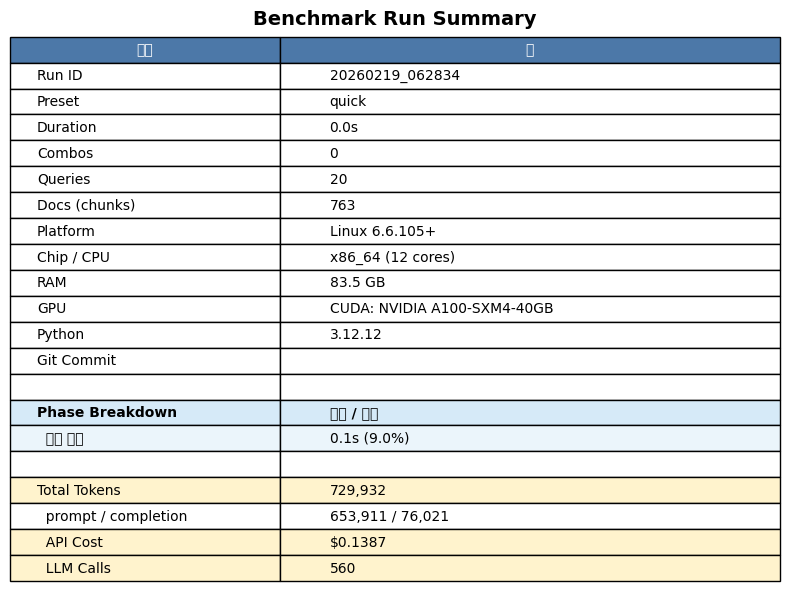


--- Phase Timeline ---


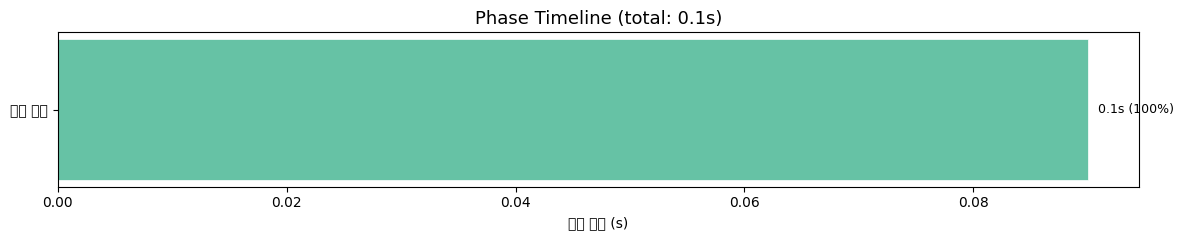

In [ ]:
# 수행 이력 요약 (RunTracker 연동)
run_record = runner.get_run_record()
if run_record:
    from colab_visualizer import plot_run_info, plot_phase_timeline
    print("--- Run Summary ---")
    plot_run_info(run_record)
    print("\n--- Phase Timeline ---")
    plot_phase_timeline(run_record)
else:
    print("RunTracker 데이터가 없습니다.")

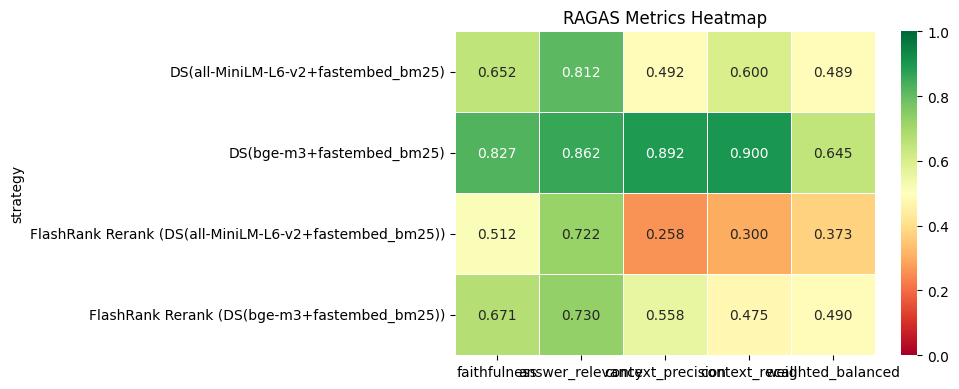

In [ ]:
# 히트맵 (전략 x 메트릭)
from colab_visualizer import plot_ragas_heatmap
plot_ragas_heatmap(ragas_df)

In [ ]:
# 파레토 프론티어 (레이턴시 vs 품질)
from colab_visualizer import plot_latency_vs_quality
plot_latency_vs_quality(latency_df, ragas_df)

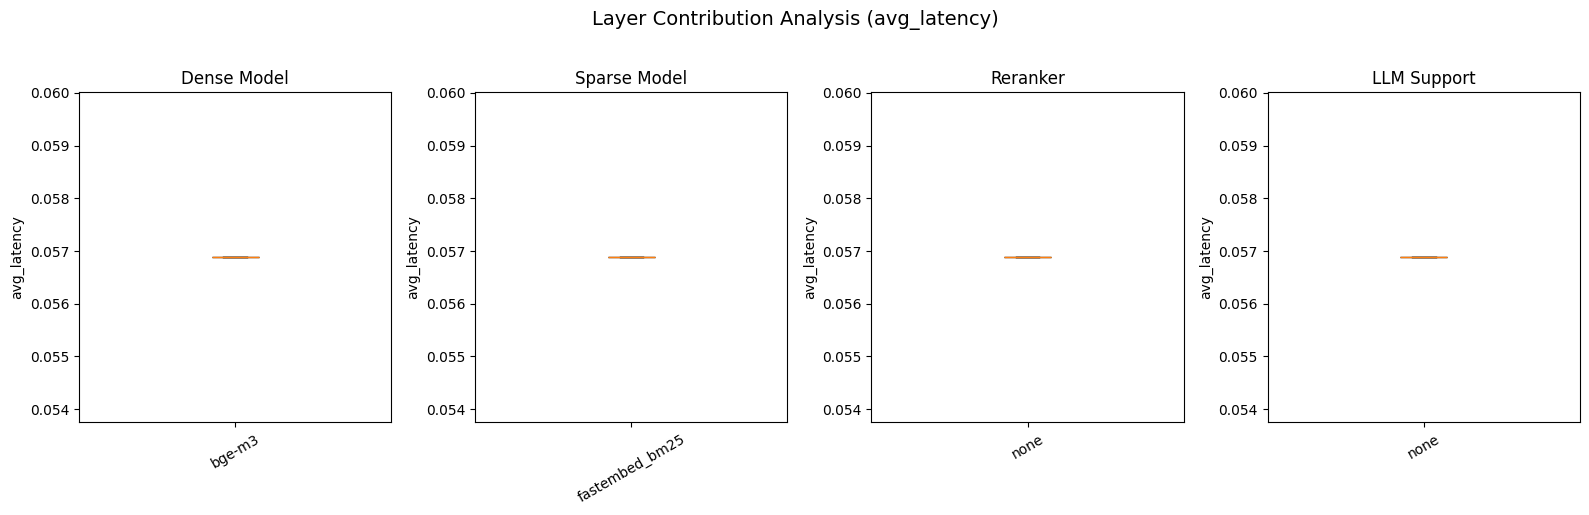

In [ ]:
# 레이어별 기여도 분석
from colab_visualizer import plot_layer_contribution
plot_layer_contribution(combos, latency_df, metric="avg_latency")

In [ ]:
# [H1] Ablation Waterfall — 레이어별 품질 기여도
from colab_visualizer import plot_ablation_waterfall
plot_ablation_waterfall(ragas_df)

In [ ]:
# [H3] Layer Interaction Heatmap — Dense × Sparse 조합 상호작용
from colab_visualizer import plot_layer_interaction_heatmap
plot_layer_interaction_heatmap(ragas_df)

In [ ]:
# [H4] Tradeoff Bubble Chart — 레이턴시 × 품질 × 비용
from colab_visualizer import plot_tradeoff_bubble
plot_tradeoff_bubble(latency_df, ragas_df, run_record=run_record)

---
## Section 8: 비용 요약 + 결과 저장

예상 API 비용:
  RAGAS 평가 (GPT-4o-mini): $0.40
  Answer 생성 (GPT-3.5-turbo): $0.08
  GraphRAG 인덱싱 (LLM): $0.00
  총계: $0.48


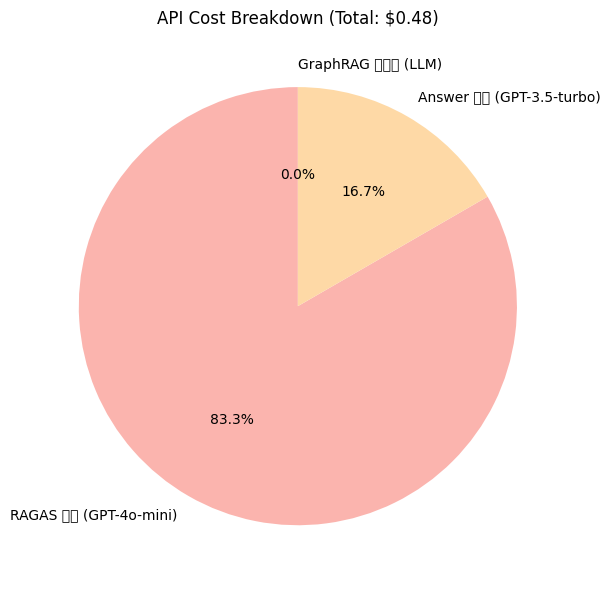

In [ ]:
# 비용 요약 (추정)
n_ragas_strategies = len(ragas_df) if ragas_df is not None else 0
n_queries = len(queries)
est_ragas_cost = n_ragas_strategies * n_queries * 0.005  # ~$0.005/query/strategy

cost_data = {
    "RAGAS 평가 (GPT-4o-mini)": est_ragas_cost,
    "Answer 생성 (GPT-3.5-turbo)": n_ragas_strategies * n_queries * 0.001,
}
total_cost = sum(cost_data.values())

print(f"예상 API 비용:")
for k, v in cost_data.items():
    print(f"  {k}: ${v:.2f}")
print(f"  총계: ${total_cost:.2f}")

from colab_visualizer import plot_cost_breakdown
if total_cost > 0:
    plot_cost_breakdown(cost_data)

In [ ]:
# 결과 Export (Google Drive)
output_dir = runner.export_results(
    latency_df=latency_df,
    ragas_df=ragas_df,
)
print(f"\n결과 저장 위치: {output_dir}")

  레이턴시: /content/drive/MyDrive/rag_bench_colab/results/quick_20260219_062834/latency.csv
  RAGAS: /content/drive/MyDrive/rag_bench_colab/results/quick_20260219_062834/ragas.csv
  per-sample 결과: /content/drive/MyDrive/rag_bench_colab/results/quick_20260219_062834/per_sample/ (4개)

  [RunTracker] 수행 이력 저장: /content/drive/MyDrive/rag_bench_colab/_benchdata/run_history/run_20260219_062834.json
  [RunTracker] 총 소요: 871.0s, 성공: 0, 실패: 0
  [RunTracker] 토큰 총계: 729,932 (prompt: 653,911, completion: 76,021, calls: 560, cost: $0.1387)
  [RunTracker] 단계별 소요 (총 871.0s):
    chunking: 0.09s (0.0%)
  수행 이력: /content/drive/MyDrive/rag_bench_colab/results/quick_20260219_062834/run_20260219_062834.json
  리포트: /content/drive/MyDrive/rag_bench_colab/results/quick_20260219_062834/report.md

[Export] 결과 저장 완료: /content/drive/MyDrive/rag_bench_colab/results/quick_20260219_062834

결과 저장 위치: /content/drive/MyDrive/rag_bench_colab/results/quick_20260219_062834


In [ ]:
# HTML 보고서 열기
from IPython.display import HTML, display
html_path = output_dir / 'report.html'
if html_path.exists():
    display(HTML(f'<a href="{html_path}" target="_blank">📊 HTML 보고서 열기</a>'))
    print(f'HTML 보고서: {html_path}')
else:
    print('[Info] HTML 보고서가 아직 생성되지 않았습니다.')